# Answers

You can edit this Jupyter notebook to include your answers and run any code that generates those answers or produces plots.  You can add additional cells for code or markdown as needed.

This homework is primarily about running simulations involving initial value problems (IVPs) and a simple PDE.

In [2]:
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from scipy.integrate import DenseOutput
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import scipy.sparse as sparse
from sympy import Function, dsolve, Eq, Derivative, sin, cos, symbols
from scipy.integrate import solve_ivp
import importlib

## Problem 0 (30 points)

In this problem, you will implement a custom ODE solver for `solve_ivp` based on the Forward Euler method, and implement some basic tests.

### Part A (20 points)
If you read the [documentation for `solve_ipv`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html), which we used in class, you'll see that you can write your own solver.

Write a solver for the forward Euler method, which is not implemented as one of the available solvers (while simple, it typically is not very accurate).  Recall, this is the basic rule:
\begin{equation}
y(t + h) = y(t) + h f(t, y)
\end{equation}

Your solver should be a class which is derived from [`scipy.integrate.OdeSolver`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.OdeSolver.html#scipy.integrate.OdeSolver)
```python
class ForwardEuler(scipy.integrate.OdeSolver):
    pass
```

Your class definition should go in [`euler.py`](euler.py)

You should read the documentation for this base class in order to implement `ForwardEuler`.  Here are some hints/notes:
* Allow a user to set `h` using a keyword argument.  This can be passed using `solve_ivp(..., method=ForwardEuler, h=0.01)` to set `h=0.01`
* Use a default step size `h = (t_bound - t0) / 100`
* private methods begin with an underscore "_"
* the method `_dense_output_impl(self)` should output a `ForwardEulerOutput` (defined in [`euler.py`](euler.py))
* direction should be `+1`
* You won't use a Jacobian, so `njev` and `nlu` can remain at 0.
* You may want to consider using `super(ForwardEuler, self).__init__`
* You may want to read the source code for the parent class [here](https://github.com/scipy/scipy/blob/v1.5.3/scipy/integrate/_ivp/base.py#L25-L214)

---

*put any discussion here*

• The solver takes a step size h as input, with a default of (t_bound - t0)/100 if not specified.  
• At each step, I calculate the new value using y_new = y_old + h * f(t, y_old). For dense output, I just do linear interpolation between steps.  
• Forward Euler is really easy to implement but not very accurate. The method worked fine for simple problems like exponential growth, but for   oscillatory problems it was not great.  
• Smaller step sizes give better accuracy but take longer to run.

In [4]:
from euler import ForwardEuler
from sympy.abc import x # x is overwritten in previous cells so we need to import here

### Part B (10 points)

Use your `ForwardEuler` solver and `solve_ivp` to solve an IVP $y'(t) = y$ with $y(0) = 1$ on the domain $t\in [0,5]$, using a step size `h=0.01`.  Make a plot of the solution to this IVP with axes labeled `y` and `x`.

Use SymPy to obtain the ground-truth solution to this IVP.  What is the largest error you see on the domain you solved the problem?  Try solving with the default solver in `solve_ivp`.  What is the largest error in this case?

---

*put your answers here*

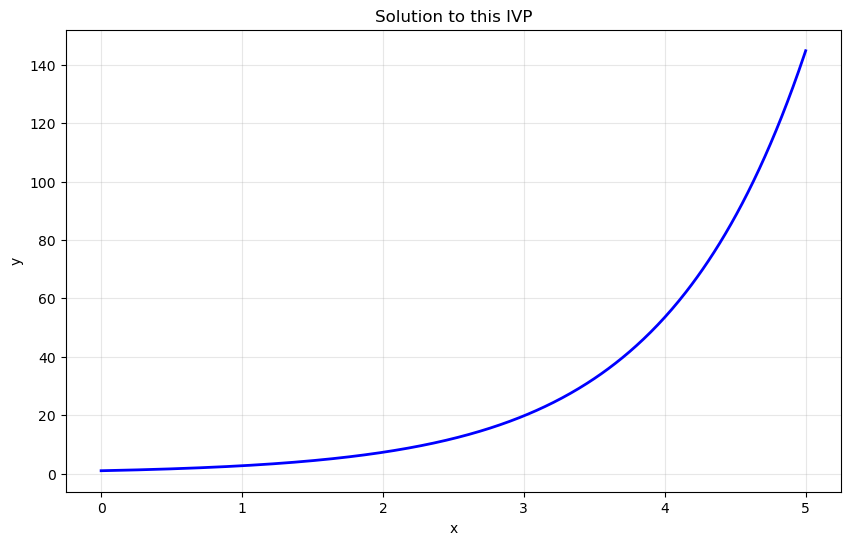

Ground-truth solution: Eq(y(t), exp(t))
Largest error on the domain: 3.6403866699945127
Largest error with the default solver: 18.179254750874037


In [5]:
from sympy import symbols, Function, dsolve, Eq, exp

t_span = (0, 5)
y0 = [1]
h = 0.01

def exponential_ode(t, y):
    return y # y' = y

sol_euler = solve_ivp(exponential_ode, t_span, y0, method=ForwardEuler, h=h)

# Make a plot of the solution to this IVP
plt.figure(figsize=(10, 6))
plt.plot(sol_euler.t, sol_euler.y[0], 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solution to this IVP')
plt.grid(True, alpha=0.3)
plt.show()

# Use SymPy to obtain the ground-truth solution
t_sym = symbols('t')
y_sym = Function('y')(t_sym)
ode_eq = Eq(y_sym.diff(t_sym), y_sym)
real_sol = dsolve(ode_eq, y_sym, ics={y_sym.subs(t_sym, 0): 1})
print(f"Ground-truth solution: {real_sol}")

def real_solution(t):
    return np.exp(t)

# Largest error on the domain
t_dense = np.linspace(0, 5, 1000)

y_real_dense = real_solution(t_dense)
y_euler_dense = np.interp(t_dense, sol_euler.t, sol_euler.y[0])
error_euler = np.abs(y_euler_dense - y_real_dense)
max_error_euler = np.max(error_euler)
print(f"Largest error on the domain: {max_error_euler}")

# Solve with the default solver in solve_ivp
sol_default = solve_ivp(exponential_ode, t_span, y0, method='RK45')

y_default_dense = np.interp(t_dense, sol_default.t, sol_default.y[0])
error_default = np.abs(y_default_dense - y_real_dense)
max_error_default = np.max(error_default)
print(f"Largest error with the default solver: {max_error_default}")


### Part C (optional challenge)

Use Richardson (see Problem 0) on your Forward Euler solver. How does the error change? You can assume that $m=1$ and derive the formula analytically. What happens if you do Richardson twice?

In [6]:
t_span = (0, 2)
y0 = [1]

h_values = [0.1, 0.05, 0.025, 0.0125]
solutions = []

for h in h_values:
    sol = solve_ivp(exponential_ode, t_span, y0, method=ForwardEuler, h=h)
    solutions.append(sol)

t_common = np.linspace(0, 2, 200)
y_exact = real_solution(t_common)

y_interp = []
for sol in solutions:
    y_interp.append(np.interp(t_common, sol.t, sol.y[0]))

# Richardson
R1 = 2 * y_interp[1] - y_interp[0]  # use h=0.05 and h=0.1
R2 = 2 * y_interp[2] - y_interp[1]  # use h=0.025 and h=0.05
R3 = 2 * y_interp[3] - y_interp[2]  # use h=0.0125 and h=0.025

# Richardson twice
R_final = (4 * R2 - R1) / 3

# Error
errors = []
for y in y_interp:
    errors.append(np.abs(y - y_exact))
    
errors.append(np.abs(R1 - y_exact))
errors.append(np.abs(R_final - y_exact))

print("Richardson Error:")
for i, h in enumerate(h_values):
    print(f"h={h}: Largest error = {np.max(errors[i])}")
print(f"Largest error with Richardson Once: {np.max(errors[4])}")  
print(f"Largest error with Richardson Twice: {np.max(errors[5])}")

Richardson Error:
h=0.1: Largest error = 0.6615561496050528
h=0.05: Largest error = 0.34906738680600924
h=0.025: Largest error = 0.17948828270113282
h=0.0125: Largest error = 0.0910352138135524
Largest error with Richardson Once: 0.04079611079397427
Largest error with Richardson Twice: 0.0024353218699006973


## Problem 1 (20 points)

Now that you're warmed up, here are some more simulations.

### Part A (15 points)

In this problem, we'll simulate a planet and moon moving in a 2-dimensional plane.

Newton's law of gravity says that $F_g = Gm_1 m_2 / \|r\|^2$.  The direction of the force is in the direction of the vector $r$.  Let $x(t)$ dentote the position of the planet and $y(t)$ denote the position of the moon, and $r(t) = x(t) - y(t)$ Then
\begin{equation}
x''(t) = -F_g / m_1 \times r / \|r\|\\
y''(t) = F_g / m_2 \times r / \|r\|
\end{equation}
$x$ and $y$ are 2-vectors, so this is a system of 4-second order ODEs.  We can use the following trick to write this as 8 first order ODEs. Let $p(t)$ be the velocity of the planet and $q(t)$ be the velocity of the moon (note that they are vector valued!). So, $p(t) = x'(t)$, and $q(t) = y'(t)$.  Here are the terms for $x$:
\begin{equation}
p_1'(t) = -F_g / m_1 \times r_1(t) / \|r\|\\
p_2'(t) = -F_g / m_1 \times r_2(t) / \|r\|\\
x_1'(t) = p_1(t)\\
x_2'(t) = p_2(t)
\end{equation}

\begin{equation}
q_1'(t) = F_g / m_2 \times r_1(t) / \|r\|\\
q_2'(t) = F_g / m_2 \times r_2(t) / \|r\|\\
y_1'(t) = q_1(t)\\
y_2'(t) = q_2(t)
\end{equation}

We'll model the Earth and moon.  The [Gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant) has value `G=6.67 e-11` (we're dropping units, which are all SI).  The mass of the earth is `m1 = 5.972 e24`, and the mass of the moon is `m2=0.07346 e24`.  The distance from the moon to the earth is `r = 384.4 e6`.  This means the orbital speed of the moon around the earth is about `1.022 e3`.

Use `solve_ivp` to run a simulation of the moon orbiting the earth for `5 e6` seconds (about 2 months).  Use initial conditions $x(0) = 0, p(0) = 0$ for the earth, and $y(0) = (0, 384.4 \times 10^6)$ and $q(0) = (1.022 \times 10^3, 0)$

Plot $x_1(t), x_2(t)$ and $y_1(t), y_2(t)$ in the same plane with different colors (include a legend and title).

---

*Put any answers/discussion here*

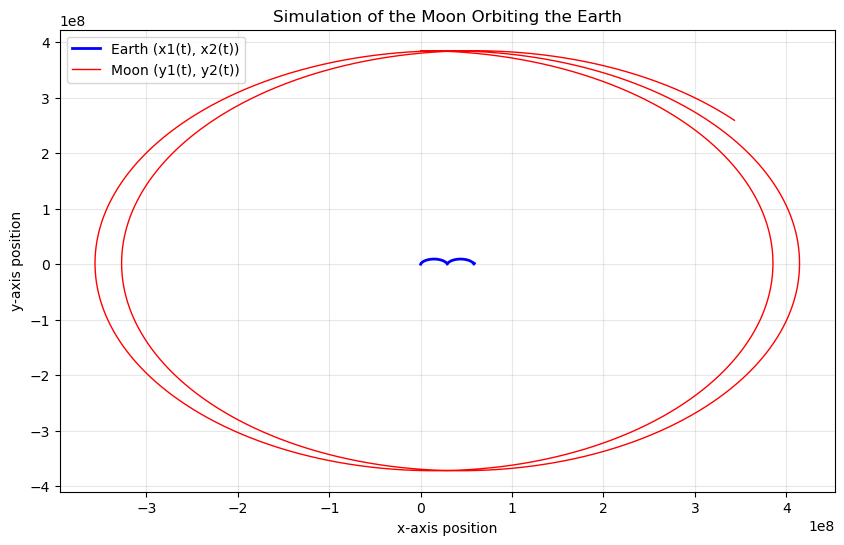

In [7]:
# Set constants
G = 6.67e-11  # Gravitational constant
m1 = 5.972e24  # Earth mass
m2 = 0.07346e24  # Moon mass
r_distance = 384.4e6  # Earth-Moon distance
v_moon = 1.022e3  # Moon orbital speed

def ODE_system(t, position):
    """
    x and y are 2-vectors, so this is a system of 4-second order ODEs.
    
    position vector: [x1, x2, vx1, vx2, y1, y2, vy1, vy2]
    x1, x2: Earth position coordinates
    y1, y2: Moon position coordinates

    vx1, vx2: Earth speed components
    vy1, vy2: Moon speed components
    """
    x1, x2, vx1, vx2, y1, y2, vy1, vy2 = position
    
    # Relative distance
    r_vec = np.array([x1 - y1, x2 - y2])
    r_norm = np.linalg.norm(r_vec)
    
    # Gravitational force magnitude
    F_g = G * m1 * m2 / (r_norm**2)
    
    # Unit direction vector
    r_unit = r_vec / r_norm
    
    # Earth acceleration (p' = dv/dt)
    p1_prime = -F_g / m1 * r_unit[0]
    p2_prime = -F_g / m1 * r_unit[1]
    
    # Moon acceleration (q' = dv/dt)  
    q1_prime = F_g / m2 * r_unit[0]
    q2_prime = F_g / m2 * r_unit[1]
    
    return [vx1, vx2, p1_prime, p2_prime, vy1, vy2, q1_prime, q2_prime]

# Initial conditions
x0 = [0, 0]      # Earth position
p0 = [0, 0]      # Earth speed

y0 = [0, r_distance]  # Moon position  
q0 = [v_moon, 0]      # Moon speed

initial_position = x0 + p0 + y0 + q0

# Simulation
t_span = (0, 5e6)  # run a simulation of the moon orbiting the earth for 5 e6 seconds (about 2 months)
t_eval = np.linspace(0, 5e6, 10000)  # Evaluation points

sol = solve_ivp(ODE_system, t_span, initial_position, t_eval=t_eval, method='RK45', rtol=1e-8)

x1 = sol.y[0]
x2 = sol.y[1]
y1 = sol.y[4]
y2 = sol.y[5]

# Plot x1(t), x2(t) and y1(t), y2(t) in the same plane
plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b-', linewidth=2, label='Earth (x1(t), x2(t))')
plt.plot(y1, y2, 'r-', linewidth=1, label='Moon (y1(t), y2(t))')
plt.xlabel('x-axis position')
plt.ylabel('y-axis position')
plt.title('Simulation of the Moon Orbiting the Earth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Part B (5 points)

Now simulate a system with 10 planets, in 10 random locations. The planets should have random masses chosen independently and uniformly from the interval $[0,6 \times 10^{24}]$ and initial locations chosen randomly from the $(8 \times 10^8) \times (8\times 10^8)$ square centered at the origin. The components of each planet's initial velocity should be chosen randomly on $[-5\times 10^{2}, 5 \times 10^{2}].$ Plot the positions of each planet as a function of time.

---

*Your answer here.  You can create some code cells as well*

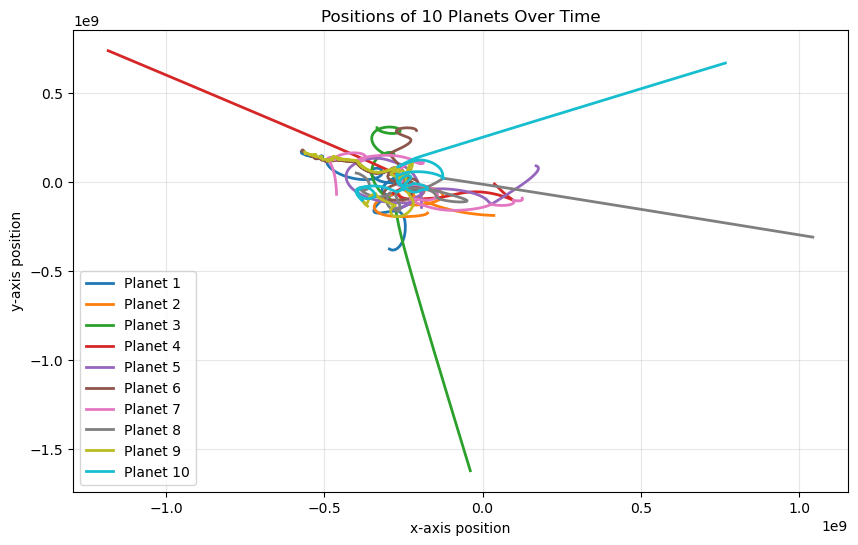

In [8]:
num = 10  # number of planets
masses = np.random.uniform(0, 6e24, num)  # random masses chosen indenpendently and uniformly
locations = np.random.uniform(-4e8, 4e8, (num, 2))  # random initial locations chosen from square centered at the origin
velocities = np.random.uniform(-500, 500, (num, 2))  # random initial velocities

def multiple_planets_system(t, position):
    """
    position vector: [x1, y1, vx1, vy1, x2, y2, vx2, vy2, ...]
    """
    n = len(position) // 4
    deriv = np.zeros_like(position)
    pos_x = position[::4]
    pos_y = position[1::4]

    # Position derivatives are just velocities: dx/dt = vx, dy/dt = vy
    deriv[::4] = position[2::4]
    deriv[1::4] = position[3::4]
    
    # Aaccelerations for each planet
    for i in range(n):
        ax, ay = 0, 0
        
        for j in range(n):
            if i != j:
                dx = pos_x[i] - pos_x[j]
                dy = pos_y[i] - pos_y[j]
                r = np.sqrt(dx**2 + dy**2)
                
                # Acceleration from planet j
                a = G * masses[j] / r**3
                ax -= a * dx
                ay -= a * dy
        
        deriv[4*i + 2] = ax  # dvx/dt
        deriv[4*i + 3] = ay  # dvy/dt
    
    return deriv

# Initial position vector
initial_position = []
for i in range(num):
    initial_position.extend([locations[i, 0], locations[i, 1], 
                         velocities[i, 0], velocities[i, 1]])

initial_position = np.array(initial_position)

# Simulation
t_span = (0, 5e6)  # run a simulation of 10 planets for 5 e6 seconds (about 2 months)
t_eval = np.linspace(0, 5e6, 10000)  # Evaluation points

sol = solve_ivp(multiple_planets_system, t_span, initial_position, t_eval=t_eval, method='RK45', rtol=1e-8)

# Plot the positions of each planet as a function of time
plt.figure(figsize=(10, 6))

for i in range(num):
    x_pos = sol.y[4*i]  # x positions for planet i
    y_pos = sol.y[4*i + 1]  # y positions for planet i
    plt.plot(x_pos, y_pos, linewidth=2, label=f'Planet {i+1}')

plt.xlabel('x-axis position')
plt.ylabel('y-axis position')
plt.title('Positions of 10 Planets Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Problem 2 (30 points)
In this problem, we will solve some a simple PDE using the "method of lines". In this method, we replace the
$$\partial_t u(t,x) = \Delta u(t,x) $$
PDE by the system of ODEs
$$ \partial_t\boldsymbol{u}(t) = A \boldsymbol{u}(t),$$
where
$$[\boldsymbol{u}(t)]_i=u_i(t) \approx u(t,x_i). $$
The matrix $A$ approximates the differential operator using, e.g. finite differences
$$ \Delta u \to A \boldsymbol{u}.$$

After we semi-discretize in space we are left with a large system of ODEs that we can solve using our favorite method.
 

### Part A (25 points)
In this problem we will solve the heat equation 
\begin{equation}
\begin{cases}
\partial_t u(t,x) = \Delta u(t,x) & x\in [0,1], \;t\in[0,T]\\
u(0,x) = f(x) & x\in [0,1]\\
u(t,0) = a & t \in [0,T]\\
u(t,1) = b & t \in [0,T]\\
\end{cases}
\end{equation}
with the method of lines.

To solve this equation, we discretize the interval $x\in[0,1]$ with $n+2$ points. The end points will be used to enforce boundary conditions and the interior points will be used to compute the right hand side of the PDE. We approximate the Laplacian operator using the second order centered difference formula
$$g''(x) = \frac{g(x+h)-2g(x)+g(x-h)}{h^2}$$
and we integrate in time using the forward Euler method.

Your code for implementing this method should include the following three functions
1. `second_diff`, which computes the second derivative of $u$ at the interior nodes (using the centered difference formula) and returns it as an array with zeros on each end (as the boundary conditions don't change)
2. `forward_time_step`, which uses $u(t_n,x)$ and the forward Euler method to compute $u(t_{n+1},x)$
3. `sim_heat`, which solves the heat equation by setting $u(0,x)=f(x)$ and then calling `forward_time_step` repeatedly to compute $u(T,x)$. This function should accept the following inputes
    * `n` the number of internal nodes 
    * `f` the initial condition
    * `bc` a list containing the left and right boundary conditions $a$ and $b$
    * `dx` the grid spacing, i.e. the distance between x values i.e. $1/(n+1)$
    * `dt` the time step to be used by the forward Euler method
    * `T` the time at which we want the solution $u(T,x)$. Note that in general $T/dt$ will not be an integer, so the last call of `forward_time_step` will have to use a smaller time step than `dt`

Once you have created these functions, solve the heat equation with
\begin{gather}
f(x) = \sin(2\pi x)\\
a = b = 0
\end{gather}
up until time $T=0.02$ using $n=99$ and `dt=0.2*dx**2`. 

To verify the accuracy of your code, compare the output to the exact solution $u(t,x)= \exp(-4\pi^2t)\sin(2\pi x)$. You can do this by summing the sum of squares errors at your $x_i$'s and dividing by $\sqrt{n}$.

You should also include a plot of $u(0,x)$ and $u(T,x)$.

Verify Accuracy: error is 1.6760692451215578e-05


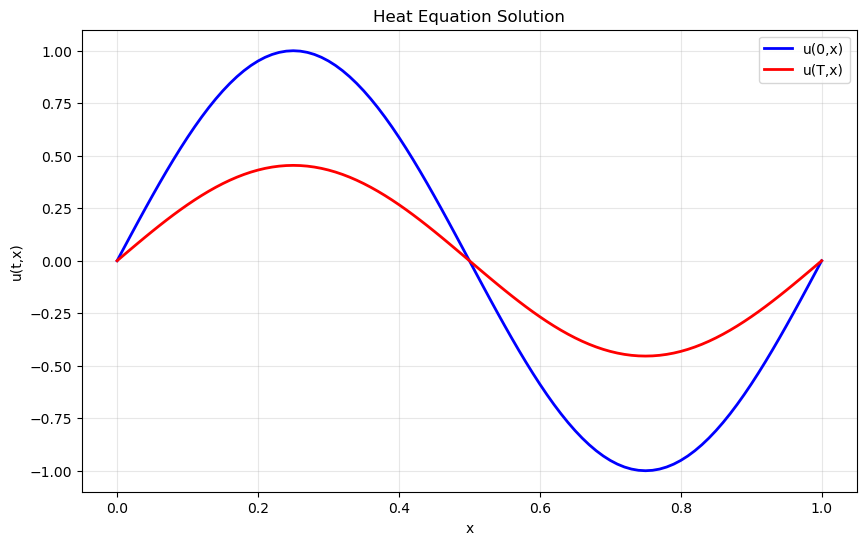

In [8]:
def second_diff(u,dx):
    """
    Compute the second derivative of u at the interior nodes
    """
    n = len(u) - 2  # number of interior points
    diff = np.zeros_like(u)  # array of second derivatives with zeros at boundaries

    # Second order centered difference
    for i in range(1, n+1):
        diff[i] = (u[i+1] - 2*u[i] + u[i-1]) / (dx**2)

    return diff


def time_step(u,dx,dt):
    u_xx = second_diff(u, dx)  # second derivative
    u_new = u + dt * u_xx

    return u_new


def sim_heat(n,f,bc,dx,dt,T):
    num_points = n + 2  # total number of points include boundries

    x = np.linspace(0, 1, num_points)

    u = f(x)  # set u(0,x) = f(x)
    u[0] = bc[0]  # left boundary
    u[-1] = bc[1]  # right boundary

    t = 0
    while t < T:
        step = min(dt, T - t)  # use smaller step
        u = time_step(u, dx, step)  # Time step
        t += step

    return u, x


T = 0.02
n = 99
dx = 1.0 / (n + 1)
dt = 0.2 * dx**2

# Heat equation
def f(x):
    return np.sin(2 * np.pi * x)

bc = [0, 0]  # a = b = 0

# Solve the heat equation
u_sol, x = sim_heat(n, f, bc, dx, dt, T)

# Exact solution
def exact_solution(t, x):
    return np.exp(-4 * np.pi**2 * t) * np.sin(2 * np.pi * x)

u_exact = exact_solution(T, x)

# Compare output to exact solution
error = u_sol - u_exact  # errors at xi
compare_error = np.sqrt(np.sum(error**2) / n)
print(f"Verify Accuracy: error is {compare_error}")

# Plot results
plt.figure(figsize=(10, 6))

plt.plot(x, f(x), 'b-', linewidth=2, label='u(0,x)')
plt.plot(x, u_sol, 'r-', linewidth=2, label=f'u(T,x)')

plt.xlabel('x')
plt.ylabel('u(t,x)')
plt.title('Heat Equation Solution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Part B (5 points)
Now solve for $u(T,x)$ using the same parameters as above, except that you should set `dt=0.7*dx**2`. Create a plot of $u(0,x)$ and $u(T,x)$ and compare it to the plot from the previous question. The ratio $dt/dx^2$ is called the CFL (Courant–Friedrichs–Lewy) number and the observation that you will make is an important concept in numerical PDE methods.

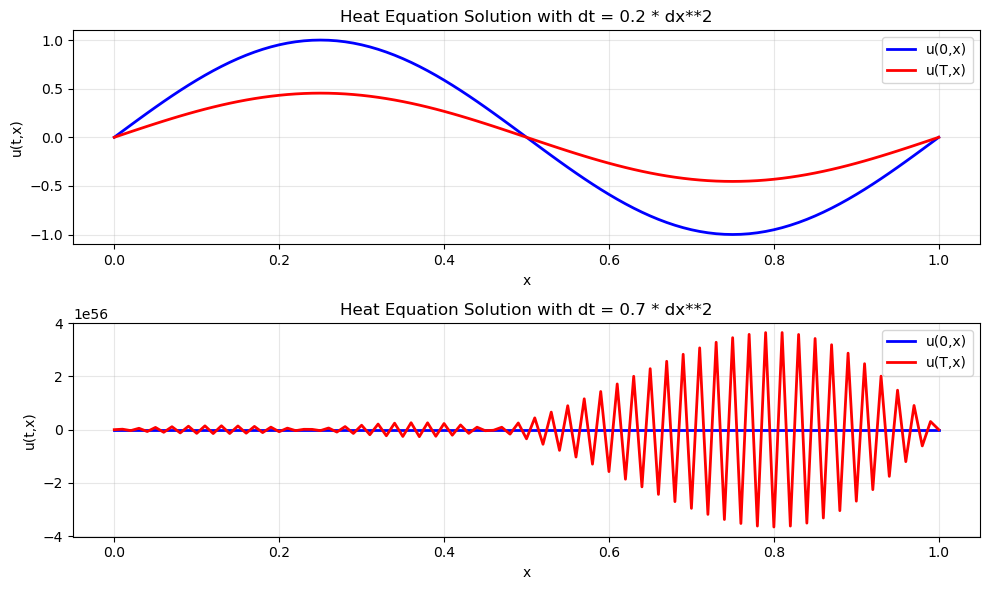

In [14]:
# Set new dt
dt_new = 0.7 * dx**2

# Solve the heat equation
u_sol_new, x = sim_heat(n, f, bc, dx, dt_new, T)

# Plot results
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(x, f(x), 'b-', linewidth=2, label='u(0,x)')
plt.plot(x, u_sol, 'r-', linewidth=2, label=f'u(T,x)')
plt.xlabel('x')
plt.ylabel('u(t,x)')
plt.title('Heat Equation Solution with dt = 0.2 * dx**2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(x, f(x), 'b-', linewidth=2, label='u(0,x)')
plt.plot(x, u_sol_new, 'r-', linewidth=2, label=f'u(T,x)')
plt.xlabel('x')
plt.ylabel('u(t,x)')
plt.title('Heat Equation Solution with dt = 0.7 * dx**2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

• For the plot from Part A, CFL = 0.2, solution is smooth, showing proper decay of the sine wave over time.  
• For the plot from Part B, CFL = 0.7, solution becomes unstable and develops strong oscillations and divergence.  
• Thus, for the forward Euler method applied to the heat equation (PDE), stability requires certain CFL condition, otherwise solution will diverge.

## Part C (optional, 5 bonus points)
The CFL condition that $dt/dx^2<0.5$ is prohibitively restrictive. To get around this, we can use so-called implicit time stepping schemes, which are far more stable, though computationally costly. The simplest of these schemes is the backwards Euler method:
$$ y(t_{n+1}) = y(t_n) + dt y'(t_{n+1})$$
(Note that $y'$ is now evaluated at a future time.) When solving a linear system of ODEs
$$ y'= A y$$
the backwards Euler method requires us to solve the linear system
$$ (I - dt A)y(t_{n+1}) = y(t_{n}). $$

In this problem you should modify your existing code to solve the heat equation using this implicit time stepping scheme. In order to do this efficiently, you should construct and store a Cholesky factorization of the matrix $I-dt A$.

With this new code, repeat the experiment from part B. Do you run into the same stability problem?

Further, with this method, are you able to make $dt$ a comparable size to $dx$?

## Feedback

If you would like share how long it took you to complete this assignment, it will help adjust the difficulty for future assignments.  You're welcome to share additional feedback as well.